In [1]:
# Cell 1: Data Loading & Setup

# Install the UCI dataset helper package
!pip install -q ucimlrepo

# Import core libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset loader
from ucimlrepo import fetch_ucirepo

# Fetch the "Predict Students' Dropout and Academic Success" dataset (UCI id = 697)
student_dropout_data = fetch_ucirepo(id=697)

# Separate features (X) and target (y)
X = student_dropout_data.data.features.copy()
y = student_dropout_data.data.targets.copy()

# Make sure the target is a single pandas Series, then combine with features
if isinstance(y, pd.DataFrame):
    target_col = y.columns[0]
    y = y.iloc[:, 0]
else:
    target_col = y.name if y.name is not None else "Target"
    y = pd.Series(y, name=target_col)

# Combine features and target into one DataFrame
df = pd.concat([X, y.rename(target_col)], axis=1)

# Quick preview
print("Dataset loaded successfully.")
print(f"Feature shape: {X.shape}")
print(f"Target column: {target_col}")
display(df.head())


Dataset loaded successfully.
Feature shape: (4424, 36)
Target column: Target


,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Dataset shape: (4424, 37)

Missing values per column:
No missing values found.

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


/tmp/ipykernel_14599/1386874064.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_col, order=class_order, palette="Set2")


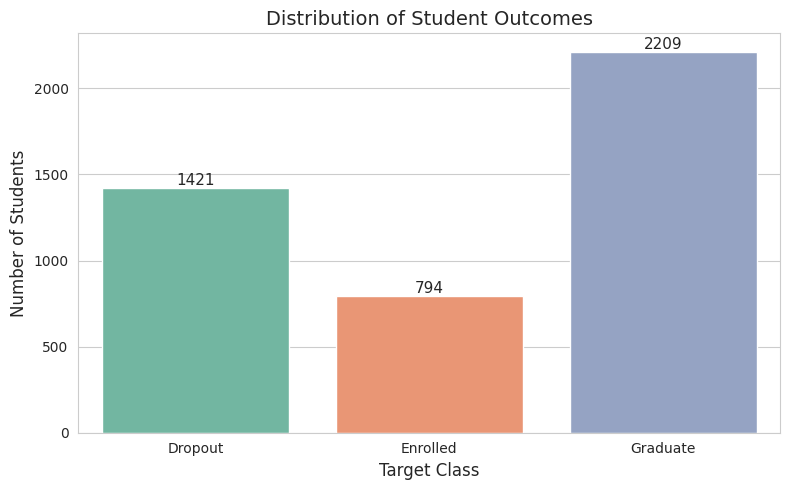

In [2]:
# Cell 2: Exploratory Data Analysis (EDA)

# Check dataset shape
print("Dataset shape:", df.shape)

# Check for missing values in each column
missing_values = df.isnull().sum()
print("\nMissing values per column:")
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "No missing values found.")

# Show target distribution counts
print("\nTarget distribution:")
print(df[target_col].value_counts())

# Set a clean plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(8, 5))

# Keep the class order consistent for presentation
class_order = [label for label in ["Dropout", "Enrolled", "Graduate"] if label in df[target_col].unique()]

# Create a bar chart for the target variable
ax = sns.countplot(data=df, x=target_col, order=class_order, palette="Set2")

# Add count labels above bars
for patch in ax.patches:
    height = int(patch.get_height())
    ax.annotate(
        f"{height}",
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.title("Distribution of Student Outcomes", fontsize=14)
plt.xlabel("Target Class", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)
plt.tight_layout()
plt.show()


In [3]:
# Cell 3: Baseline Model Preparation

# Import modeling tools
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Convert the original 3-class target into a binary target:
# 1 = Dropout
# 0 = Not Dropout (Enrolled + Graduate)
df_model = df.copy()
df_model["dropout_binary"] = (df_model[target_col] == "Dropout").astype(int)

# Prepare features and target
# We drop the original multiclass target and keep the new binary target
X_binary = df_model.drop(columns=[target_col, "dropout_binary"])
y_binary = df_model["dropout_binary"]

# Convert any non-numeric columns to numeric if needed
X_binary = pd.get_dummies(X_binary, drop_first=True)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_binary,
    y_binary,
    test_size=0.2,
    random_state=42,
    stratify=y_binary
)

# Train a simple baseline Random Forest classifier
baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)
baseline_model.fit(X_train, y_train)

# Predict on the test set
y_pred = baseline_model.predict(X_test)

# Evaluate with accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Baseline Random Forest Accuracy:", round(accuracy, 4))


Baseline Random Forest Accuracy: 0.8814


In [4]:
# Cell 4: Final Model Training

from sklearn.ensemble import RandomForestClassifier

# Initialize the final Random Forest model
# class_weight="balanced" helps compensate for class imbalance in the target
final_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

# Train the model on the training data
final_model.fit(X_train, y_train)

print("Final Random Forest model trained successfully.")


Final Random Forest model trained successfully.


Classification Report:

              precision    recall  f1-score   support

 Not Dropout       0.89      0.95      0.92       601
     Dropout       0.88      0.74      0.80       284

    accuracy                           0.88       885
   macro avg       0.88      0.85      0.86       885
weighted avg       0.88      0.88      0.88       885



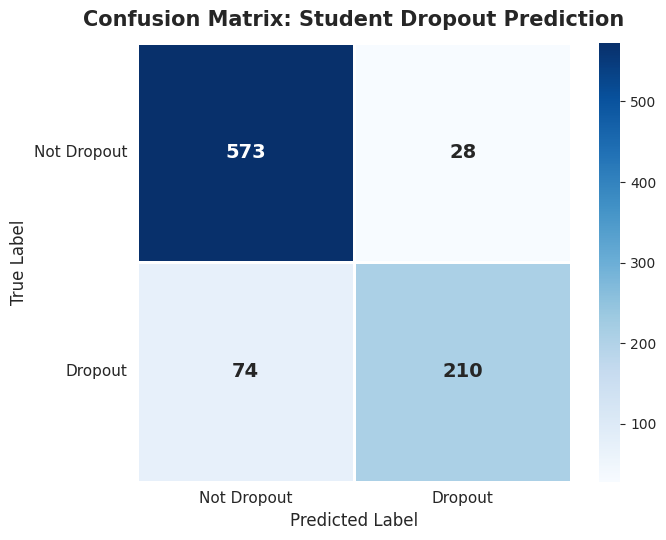

/tmp/ipykernel_14599/71092921.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


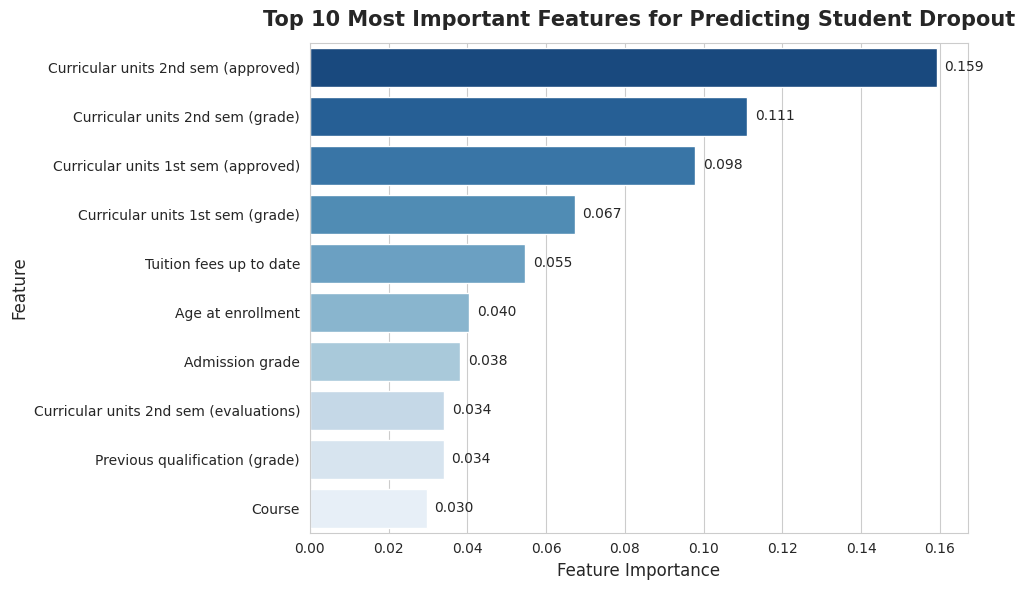

In [5]:
# Cell 5: Professional Evaluation & Visuals

from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred = final_model.predict(X_test)

# Print a full classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=["Not Dropout", "Dropout"]))

# -----------------------------
# Confusion Matrix Visualization
# -----------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5.5))
sns.set_style("white")
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    linewidths=1,
    linecolor="white",
    xticklabels=["Not Dropout", "Dropout"],
    yticklabels=["Not Dropout", "Dropout"],
    annot_kws={"size": 14, "weight": "bold"}
)

plt.title("Confusion Matrix: Student Dropout Prediction", fontsize=15, weight="bold", pad=12)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11, rotation=0)
plt.tight_layout()
plt.show()

# ---------------------------------------------
# Top 10 Feature Importances from Random Forest
# ---------------------------------------------
feature_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_model.feature_importances_
})

# Sort features by importance and keep the top 10
top_10_features = feature_importances.sort_values(
    by="Importance",
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(
    data=top_10_features,
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Top 10 Most Important Features for Predicting Student Dropout", fontsize=15, weight="bold", pad=12)
plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Feature", fontsize=12)

# Add value labels to the bars
for i, value in enumerate(top_10_features["Importance"]):
    ax.text(value + 0.002, i, f"{value:.3f}", va="center", fontsize=10)

plt.tight_layout()
plt.show()
